# Black-box optimization with finite differences

In this notebook we optimize a **black-box function** using **finite differences**. The objective is to choose the number of posts per week that maximizes an engagement score.

The function itself is stored in a separate Python file, so in the notebook we treat it as a black box: we can **evaluate** it, but we do not use an analytical derivative.

## Learning goals

By the end of the exercise you should be able to:
1. import and query a black-box function stored in a separate Python file,
2. approximate its derivative with **forward finite differences**,
3. turn a maximization problem into a minimization problem,
4. use gradient descent with a **numerical gradient**,
5. interpret how the initial point and the finite-difference step size affect the result.


## 1. Load the black-box function

The file `blackbox_.py` contains a function `f(x)` that returns an engagement score.

You should think of `f` as a **black box**:
- you can query it at any value of `x`,
- but you do not assume you know a symbolic formula,
- so you cannot differentiate it analytically inside the notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# The file blackbox_.py must be in the same folder as this notebook.
from blackbox_ import f

# Test one query
print("f(10) =", f(10.0))


f(10) = 356.5625


## 2. Visualize the black-box response

To understand the problem, we first evaluate the black box on a grid of points and plot the result.

### Exercise 1
Create a grid of values between 0 and 55, evaluate $f(x)$ on that grid, and plot the resulting curve.


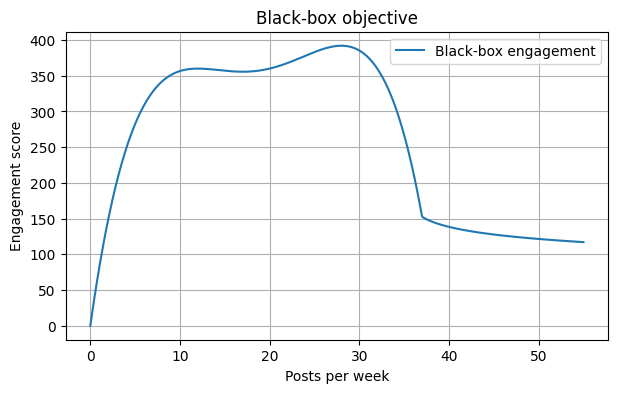

In [4]:
x_plot = np.linspace(0.0, 55.0, 800)
y_plot = np.array([f(x) for x in x_plot])

plt.figure(figsize=(7, 4))
plt.plot(x_plot, y_plot, label="Black-box engagement")
plt.xlabel("Posts per week")
plt.ylabel("Engagement score")
plt.title("Black-box objective")
plt.grid(True)
plt.legend()
plt.show()


## 3. Approximate the derivative with finite differences

Since we cannot differentiate the black box analytically, we use the **forward finite-difference** formula

$$
f'(x) \approx \frac{f(x+h)-f(x)}{h}.
$$

### Exercise 2
Implement the forward finite-difference approximation and use it to estimate the derivative at a few points.


In [5]:
def forward_difference(fun, x, h=1e-2):
    return (fun(x + h) - fun(x)) / h

test_points = [8.0, 18.0, 32.0, 45.0]
h = 1e-2

for x0 in test_points:
    d = forward_difference(f, x0, h=h)
    print(f"x = {x0:>5.1f}, approximate derivative = {d: .6f}")


x =   8.0, approximate derivative =  11.226892
x =  18.0, approximate derivative =  0.942502
x =  32.0, approximate derivative = -18.784395
x =  45.0, approximate derivative = -1.539231


## 4. Turn maximization into minimization

We want to **maximize** the engagement score $f(x)$. To use gradient descent, we define the loss

$$
J(x) = -f(x).
$$

Minimizing $J(x)$ is equivalent to maximizing $f(x)$.


In [6]:
def objective(x):
    return -f(x)

print("J(10) =", objective(10.0))


J(10) = -356.5625


## 5. Optimize with gradient descent

At each iteration we approximate the derivative of the loss numerically and update

$$
x_{k+1} = x_k - \eta\,J'_h(x_k),
$$

where $\eta$ is the learning rate and $J'_h$ is the finite-difference approximation.

### Exercise 3
Complete the optimization routine below.


In [7]:
def gradient_descent_black_box(fun, x0, eta=0.1, h=1e-2, n_steps=80, x_min=0.0, x_max=55.0):
    x = float(x0)
    xs = [x]
    history = [fun(x)]

    for _ in range(n_steps):
        grad = forward_difference(fun, x, h=h)
        x = x - eta * grad
        x = float(np.clip(x, x_min, x_max))

        xs.append(x)
        history.append(fun(x))

    return np.array(xs), np.array(history)


## 6. Run the optimization from one initial point

We now optimize the loss starting from a single initial value.

### Exercise 4
Use the routine above with:
- `x0 = 18.0`
- `eta = 0.1`
- `h = 0.05`
- `n_steps = 80`

Then:
1. print the initial and final values of `x`,
2. print the final engagement score,
3. plot the optimization path on top of the black-box curve,
4. plot the loss history.


Initial x: 18.0
Final x: 27.974967970931857
Final engagement: 391.9991406257789


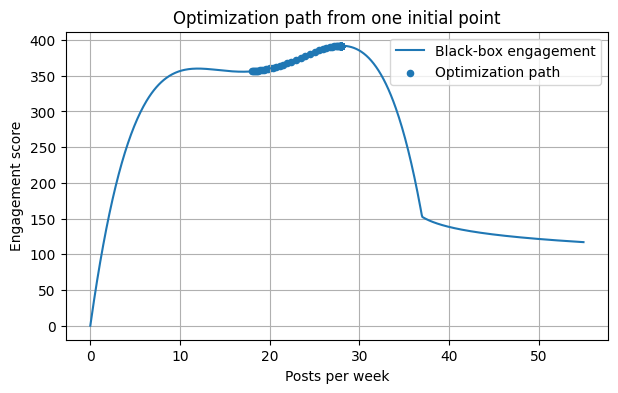

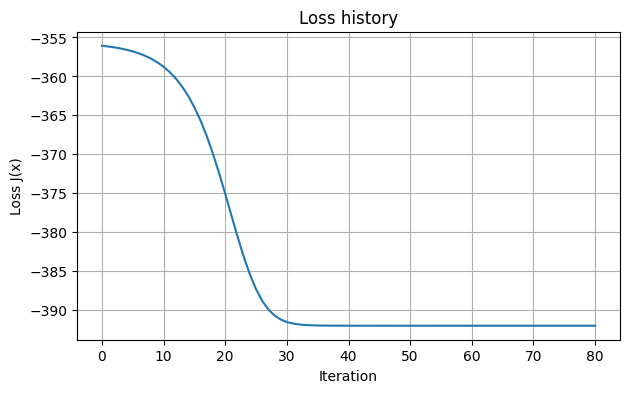

In [8]:
x0 = 18.0
eta = 0.1
h = 0.05
n_steps = 80

xs, history = gradient_descent_black_box(objective, x0=x0, eta=eta, h=h, n_steps=n_steps)

print("Initial x:", xs[0])
print("Final x:", xs[-1])
print("Final engagement:", f(xs[-1]))

plt.figure(figsize=(7, 4))
plt.plot(x_plot, y_plot, label="Black-box engagement")
plt.scatter(xs, [f(x) for x in xs], s=20, label="Optimization path")
plt.xlabel("Posts per week")
plt.ylabel("Engagement score")
plt.title("Optimization path from one initial point")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Loss J(x)")
plt.title("Loss history")
plt.grid(True)
plt.show()


## 7. Compare different initial points

The black-box function is **non-convex**, so different starting points may lead to different solutions.

### Exercise 5
Run the optimization from the initial points
`[2.0, 8.0, 18.0, 40.0]`
and compare the final result in each case.


Start =  1.0, final x =  11.9750, final engagement =  359.9996
Start =  8.0, final x =  11.9750, final engagement =  359.9996
Start = 18.0, final x =  27.9750, final engagement =  391.9991
Start = 40.0, final x =  27.9750, final engagement =  391.9991


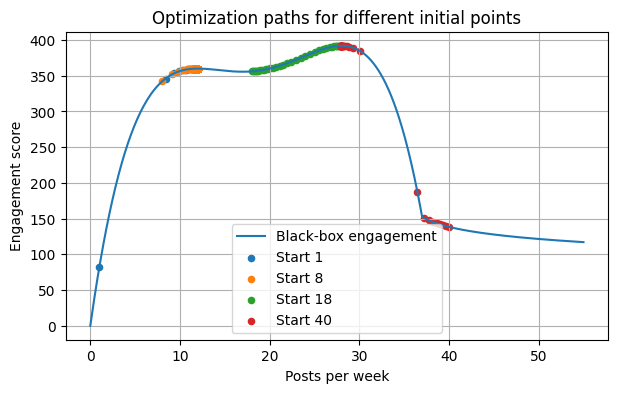

In [10]:
starts = [1.0, 8.0, 18.0, 40.0]
results = []

plt.figure(figsize=(7, 4))
plt.plot(x_plot, y_plot, label="Black-box engagement")

for x0 in starts:
    xs, history = gradient_descent_black_box(objective, x0=x0, eta=eta, h=h, n_steps=n_steps)
    results.append((x0, xs[-1], f(xs[-1])))
    plt.scatter(xs, [f(x) for x in xs], s=20, label=f"Start {x0:g}")

for x0, x_final, score_final in results:
    print(f"Start = {x0:>4.1f}, final x = {x_final: .4f}, final engagement = {score_final: .4f}")

plt.xlabel("Posts per week")
plt.ylabel("Engagement score")
plt.title("Optimization paths for different initial points")
plt.grid(True)
plt.legend()
plt.show()


## 8. Effect of the finite-difference step size

The choice of `h` affects the numerical derivative:
- if `h` is too large, the approximation is too coarse,
- if `h` is very small, numerical errors may appear.

### Exercise 6
Use the same initial point `x0 = 18.0` and compare several values of `h`.

For each value of `h`:
1. compute the approximate derivative of `J` at `x = 18.0`,
2. run the optimization,
3. record the final point and the final engagement score.


h =  0.0001 | J'(18) ≈ -0.937550 | final x =  27.9999 | final engagement =  392.0000
h =   0.001 | J'(18) ≈ -0.938000 | final x =  27.9995 | final engagement =  392.0000
h =    0.01 | J'(18) ≈ -0.942502 | final x =  27.9950 | final engagement =  392.0000
h =    0.05 | J'(18) ≈ -0.962539 | final x =  27.9750 | final engagement =  391.9991
h =     0.1 | J'(18) ≈ -0.987652 | final x =  27.9499 | final engagement =  391.9966
h =     0.5 | J'(18) ≈ -1.190918 | final x =  27.7468 | final engagement =  391.9141
h =       1 | J'(18) ≈ -1.449219 | final x =  27.4872 | final engagement =  391.6571


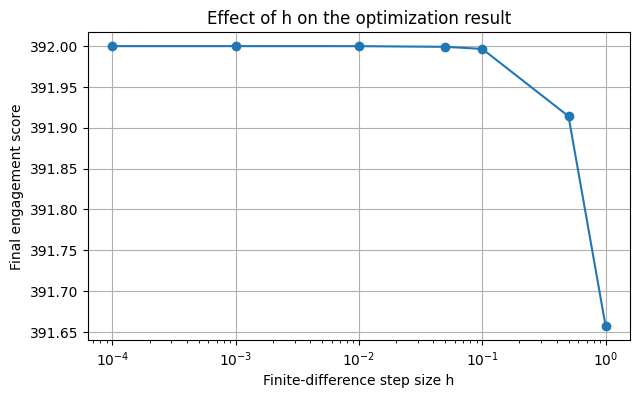

In [11]:
h_values = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1.0]

fd_values = []
final_points = []
final_scores = []

for h_val in h_values:
    fd_values.append(forward_difference(objective, 18.0, h=h_val))
    xs_h, history_h = gradient_descent_black_box(objective, x0=18.0, eta=eta, h=h_val, n_steps=n_steps)
    final_points.append(xs_h[-1])
    final_scores.append(f(xs_h[-1]))

for h_val, fd_val, x_final, score_final in zip(h_values, fd_values, final_points, final_scores):
    print(f"h = {h_val:>7g} | J'(18) ≈ {fd_val: .6f} | final x = {x_final: .4f} | final engagement = {score_final: .4f}")

plt.figure(figsize=(7, 4))
plt.semilogx(h_values, final_scores, marker="o")
plt.xlabel("Finite-difference step size h")
plt.ylabel("Final engagement score")
plt.title("Effect of h on the optimization result")
plt.grid(True)
plt.show()


## 9. Discussion

Answer these questions:

1. Why do we define `J(x) = -f(x)` instead of maximizing `f(x)` directly?
2. What does the sign of the finite-difference derivative tell you about the local behavior of the black box?
3. Why can different initial points converge to different final values?
4. How does the choice of `h` affect the quality of the optimization?
5. Why is finite-difference optimization more difficult in high dimensions?


### Possible discussion points

- Defining `J(x) = -f(x)` lets us use the standard gradient-descent update, which is formulated as a minimization method.
- The sign of the derivative tells us whether the function is locally increasing or decreasing.
- The black-box objective is non-convex, so it has more than one attractive region. Different starting points may converge to different local optima.
- If `h` is too large, the derivative estimate is too rough. If `h` is too small, floating-point errors may affect the result.
- In high dimensions, finite differences become expensive because we need many function evaluations to approximate the gradient.
